In [36]:
import numpy as np
import matplotlib.pyplot as plt
import catboost
import lightgbm
import pandas as pd
import xgboost
import tensorflow as tf
pd.set_option('display.max_columns', None)


In [37]:
# load test.csv and train.csv as pandas dataframes
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.head(), train.shape, test.head(), test.shape

In [ ]:
# find all unique values in all columns and also the count of unique values
for col in train.columns:
    print(col, train[col].nunique())
    print(train[col].unique())
    print("dtype: ", train[col].dtype)
    print("")

In [ ]:
#print how mnay have num_sold as 0 or nan
print(train[train['num_sold'].isnull() | (train['num_sold'] == 0)].shape)
#print how mnay have any column as nan or a string col as empty or id col as nan or date col as empty
print(train[train.isnull().any(axis=1) | (train['id'].isnull()) | (train['date'].str.len() == 0)].shape)
print(test[test.isnull().any(axis=1) | (test['id'].isnull()) | (test['date'].str.len() == 0)].shape)


# show head of all records where num_sold is 0 or nan
train[train['num_sold'].isnull() | (train['num_sold'] == 0)].head()



In [ ]:
import pandas as pd
import holidays
from datetime import datetime

# Assuming train and country DataFrames are already defined
# train = pd.read_csv('path_to_train.csv')
# country = pd.read_csv('path_to_country.csv')
#parse the 'date' column as datetime 
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
# Country mapping dictionary
country_mapping = {
    'Canada': 'CA',
    'Finland': 'FI',
    'Italy': 'IT',
    'Kenya': 'KE',
    'Norway': 'NO',
    'Singapore': 'SG'
}

def is_holiday(date, country_name):
    country_code = country_mapping.get(country_name)
    if country_code:
        country_holidays = holidays.CountryHoliday(country_code)
        return date in country_holidays
    return False

def get_season(date):
    month = date.month
    day = date.day
    if (month == 12 and day >= 21) or (month in [1, 2]) or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or (month in [4, 5]) or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day < 22):
        return 'Summer'
    else:
        return 'Fall'

train['is_holiday'] = train.apply(lambda row: is_holiday(row['date'], row['country']), axis=1)
train['season'] = train['date'].apply(lambda x: get_season(pd.to_datetime(x)))
train['saturday'] = train['date'].apply(lambda x: x.weekday() == 5)
train['sunday'] = train['date'].apply(lambda x: x.weekday() == 6)

test['is_holiday'] = test.apply(lambda row: is_holiday(row['date'], row['country']), axis=1)
test['season'] = test['date'].apply(lambda x: get_season(pd.to_datetime(x)))
test['saturday'] = test['date'].apply(lambda x: x.weekday() == 5)
test['sunday'] = test['date'].apply(lambda x: x.weekday() == 6)

# print("how many have saturday as True: ", train[train['saturday'] == True].shape)
# print("how many have sunday as True: ", train[train['sunday'] == True].shape)
# print("unique values in season: ", train['season'].unique())
train.head(), test.head()

In [ ]:
import pandas as pd

categorical_columns = ['country', 'store', 'product', 'is_holiday', 'season', 'saturday', 'sunday']
numerical_columns = ['num_sold']
# train = pd.get_dummies(train, columns=categorical_columns)
# Function to combine categorical columns and hash the result
num_buckets = 2000
def combined_hash(row):
    combined_string = ''.join([str(row[col]) for col in categorical_columns])
    x=  hash(combined_string)
    if(x<0):
        x%=(-num_buckets)
    else:
        x%=num_buckets
    return x 
    

# Apply the function to each row and create a new column 'hash_col'
print(train.shape)
train['hash_col'] = train.apply(combined_hash, axis=1)
print(train.shape)
print("unique values in hash_col: ", train['hash_col'].nunique())
print("range of values in hash_col: ", train['hash_col'].min(), train['hash_col'].max())
train.head()


print(test.shape)
test['hash_col'] = test.apply(combined_hash, axis=1)
print(test.shape)
print("unique values in hash_col: ", test['hash_col'].nunique())
print("range of values in hash_col: ", test['hash_col'].min(), test['hash_col'].max())
test.head()

#apply one hot encoding to the categorical columns
train = pd.get_dummies(train, columns=categorical_columns)
test = pd.get_dummies(test, columns=categorical_columns)
print(train.shape)
print(test.shape)

In [ ]:
# aaply ordinal  transformation to the date column
train['date'] = train['date'].apply(lambda x: x.toordinal())
print(train.shape)
train.head()

#apply sin cos transformation to the date column by using which date of the year out of 365 days can be represented as sin and cos
train['sin_date'] = np.sin(2 * np.pi * train['date'] / 365)
train['cos_date'] = np.cos(2 * np.pi * train['date'] / 365)
print(train.shape)
train.head()


# aaply ordinal  transformation to the date column
test['date'] = test['date'].apply(lambda x: x.toordinal())
print(test.shape)
test.head()

#apply sin cos transformation to the date column by using which date of the year out of 365 days can be represented as sin and cos
test['sin_date'] = np.sin(2 * np.pi * test['date'] / 365)
test['cos_date'] = np.cos(2 * np.pi * test['date'] / 365)
print(test.shape)
test.head()

In [ ]:
#remove all records where num_sold is nan and store those nan records in a new dataframe called nan_df
nan_df = train[train['num_sold'].isnull()]
print("shape of nan_df: ", nan_df.shape)
#remove nan_df from train
print("shape of train before removing nan_df", train.shape)
train = train.drop(nan_df.index)
print("shape of train after removing nan_df", train.shape)

In [ ]:
nan_df.shape,nan_df.head()

In [ ]:
train.head()
traincopy = train.copy()
testcopy = test.copy()
test.head()

In [56]:
train = traincopy.copy()
test = testcopy.copy()

In [57]:
import optuna
import xgboost as xgb
import catboost as cat
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

def objective(trial, train, model_type):
    # Make a copy of train
    train.drop(columns=['date', 'id'], inplace=True)
    max_leafes = 1200
    max_depth = 25
    if model_type == 'cat':
        max_depth = 16
    # Define hyperparameters to tune
    if model_type == 'xgb':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, max_leafes),
            'max_depth': trial.suggest_int('max_depth', 3, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_state': 42
        }
        model = xgb.XGBRegressor(**param)
    elif model_type == 'cat':
        param = {
            'iterations': trial.suggest_int('iterations', 100, max_leafes),
            'depth': trial.suggest_int('depth', 4, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_seed': 42,
            'silent': True
        }
        model = cat.CatBoostRegressor(**param)
    elif model_type == 'lgbm':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, max_leafes),
            'max_depth': trial.suggest_int('max_depth', 3, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_state': 42
        }
        model = lgb.LGBMRegressor(**param)
    else:
        raise ValueError("Invalid model type. Choose from 'xgb', 'cat', or 'lgbm'.")
    
    # Split the data
    X_train, X_valid, y_train, y_valid = train_test_split(train.drop(['num_sold'], axis=1), train['num_sold'], test_size=0.2, random_state=42)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Perform prediction
    predictions = model.predict(X_valid)
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_valid, predictions)
    
    return mape

def train_and_predict(train, model_type ,test):
    # Optimize hyperparameters with Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, train.copy(), model_type), n_trials=2)
    
    print(f'Best hyperparameters: {study.best_params}')
    
    # Train the model with the best hyperparameters
    best_params = study.best_params
    if model_type == 'xgb':
        model = xgb.XGBRegressor(**best_params)
    elif model_type == 'cat':
        model = cat.CatBoostRegressor(**best_params)
    elif model_type == 'lgbm':
        model = lgb.LGBMRegressor(**best_params)
    
    date_column = train['date']
    id_column = train['id']
    train.drop(columns=['date', 'id'], inplace=True)
    if model_type == 'cat' or model_type=='xgb':
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'] ,verbose=False)
    else:
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'])

    
    train['date'] = date_column
    train['id'] = id_column
    
    date_column = train['date']
    id_column = train['id']
    num_sold_actual = train['num_sold']
    train.drop(columns=['date', 'id', 'num_sold'], inplace=True)
    
    predictions = model.predict(train)
    
    decimal_found = False
    fractional_sum = 0
    for pred in predictions:
        fractional_part = pred - int(pred)
        if fractional_part != 0:
            decimal_found = True
            fractional_sum += fractional_part
    
    if decimal_found:
        print("There was a decimal number in the predictions.")
    print(f'Sum of all fractional parts: {fractional_sum}')
    
    predictions = [round(pred) for pred in predictions]
    
    train['date'] = date_column
    train['id'] = id_column
    train['num_sold'] = num_sold_actual
    
    mape = mean_absolute_percentage_error(num_sold_actual, predictions)
    print(f'Mean Absolute Percentage Error: {mape}')
    
    plt.figure(figsize=(15, 15))
    
    plt.subplot(3, 1, 1)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold')
    plt.plot(train['id'], predictions, label='Predicted num_sold', linestyle='--')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual vs Predicted Number Sold')
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold', color='blue')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual Number Sold')
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.plot(train['id'], predictions, label='Predicted num_sold', color='orange', linestyle='--')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Predicted Number Sold')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    test_id = test['id']
    test_date = test['date']
    test_pred = model.predict(test.drop(['date', 'id'], axis=1))
    test_pred = [round(pred) for pred in test_pred]
    #add tthe test_id and test_pred to a new dataframe
    test_df = pd.DataFrame({'id': test_id, 'num_sold': test_pred})
    #save the test_df to a csv file
    test_df.to_csv(f'submission.csv', index=False)
    train = traincopy.copy()
    test = testcopy.copy()


# Example usage
# train_and_predict(train_data, 'xgb')

[I 2025-01-14 10:35:38,251] A new study created in memory with name: no-name-a4aa9a8d-ab3b-4514-a8df-cf49ef20e651
[I 2025-01-14 10:35:39,876] Trial 0 finished with value: 8.686190542365484 and parameters: {'n_estimators': 117, 'max_depth': 8, 'learning_rate': 0.0003514806485613677}. Best is trial 0 with value: 8.686190542365484.
[I 2025-01-14 10:36:20,779] Trial 1 finished with value: 0.9227376737270666 and parameters: {'n_estimators': 815, 'max_depth': 15, 'learning_rate': 0.0028716132796870308}. Best is trial 1 with value: 0.9227376737270666.


Best hyperparameters: {'n_estimators': 815, 'max_depth': 15, 'learning_rate': 0.0028716132796870308}
There was a decimal number in the predictions.
Sum of all fractional parts: 111218.44017028809
Mean Absolute Percentage Error: 0.9184689307825293


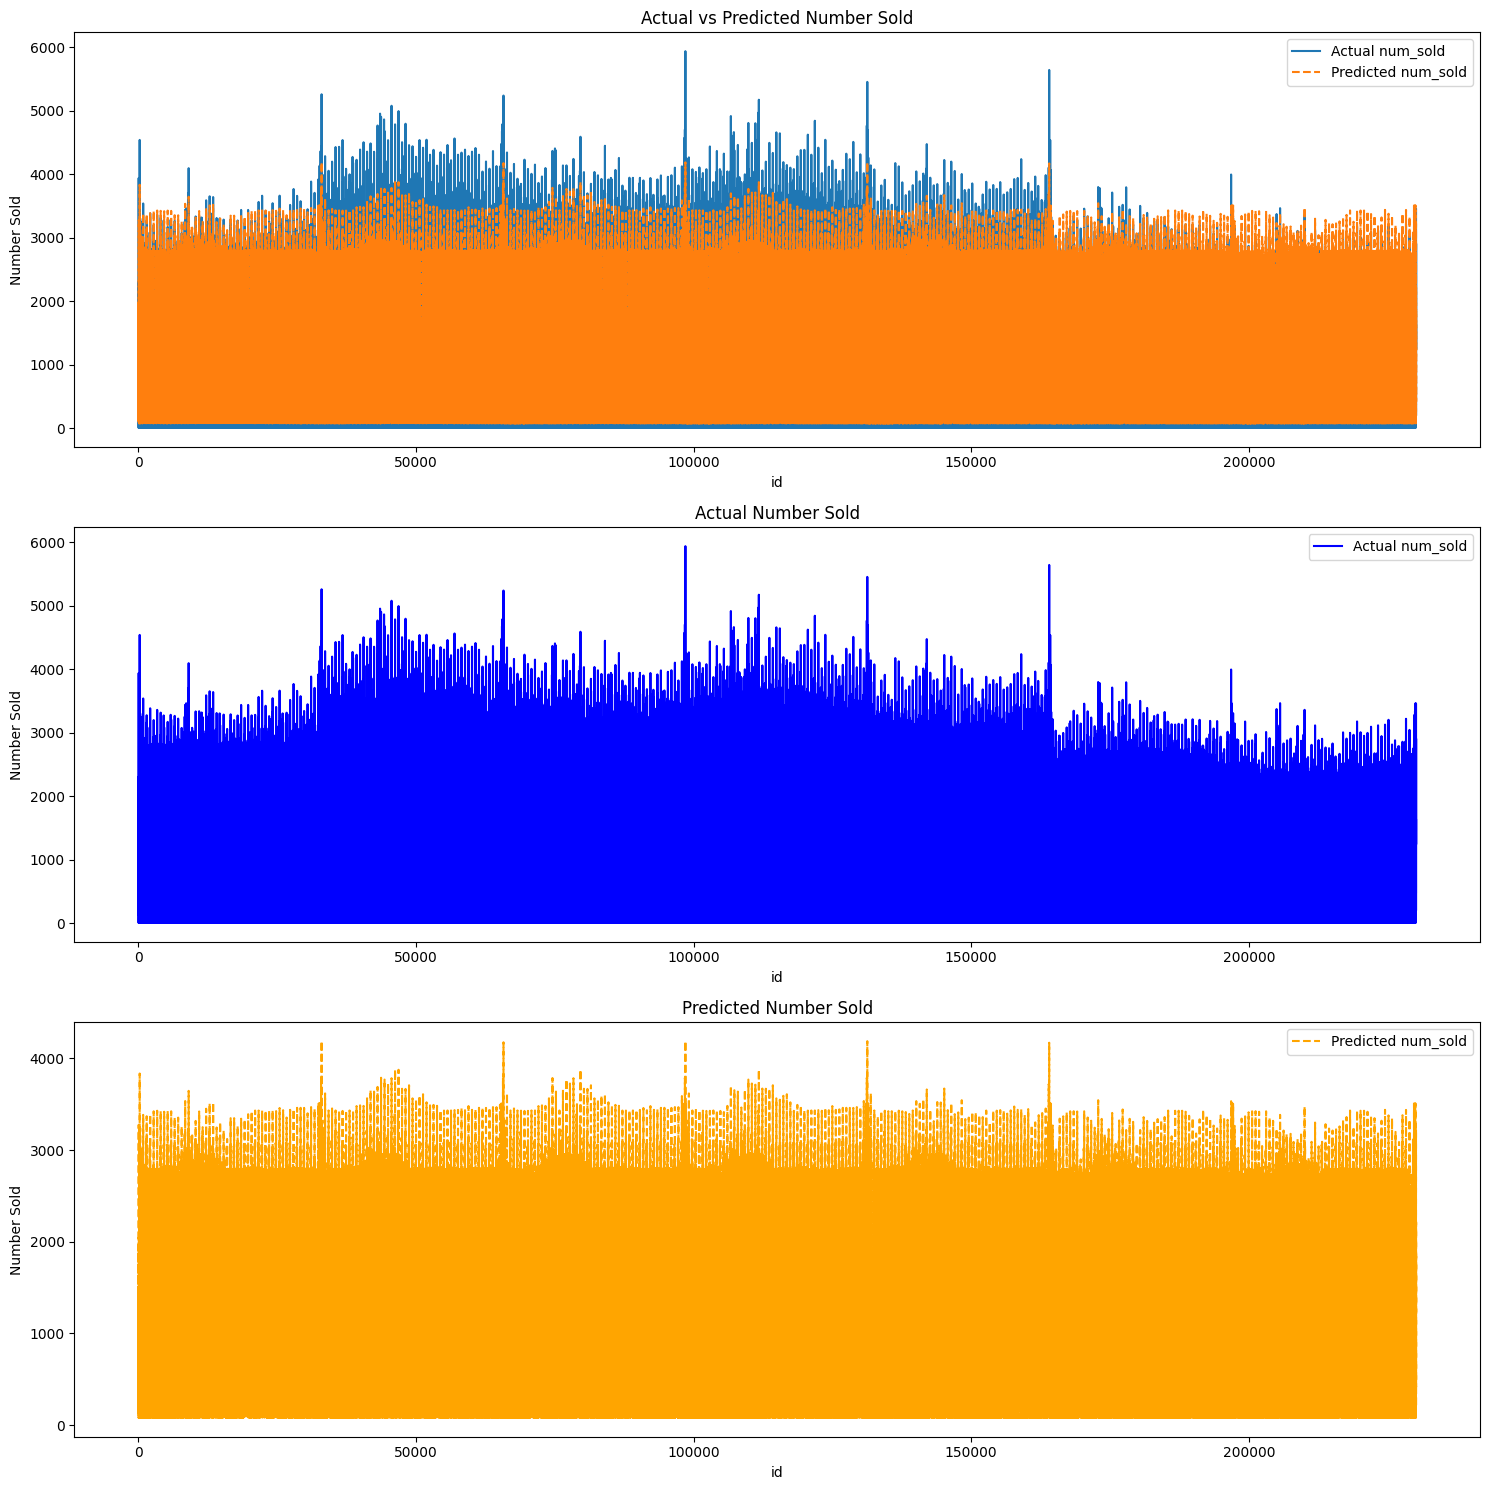

In [58]:
train_and_predict(train, 'xgb',test)


[I 2025-01-14 10:37:12,467] A new study created in memory with name: no-name-ccbd1175-ce6a-4f6d-9e18-1c1a9943bf72
[I 2025-01-14 10:38:49,024] Trial 0 finished with value: 7.148902020234931 and parameters: {'iterations': 678, 'depth': 13, 'learning_rate': 0.00035196126778869804}. Best is trial 0 with value: 7.148902020234931.
[I 2025-01-14 10:38:58,429] Trial 1 finished with value: 0.10958575580422059 and parameters: {'iterations': 125, 'depth': 11, 'learning_rate': 0.05101544458783811}. Best is trial 1 with value: 0.10958575580422059.


Best hyperparameters: {'iterations': 125, 'depth': 11, 'learning_rate': 0.05101544458783811}
There was a decimal number in the predictions.
Sum of all fractional parts: 110879.24741514298
Mean Absolute Percentage Error: 0.10997901830254406


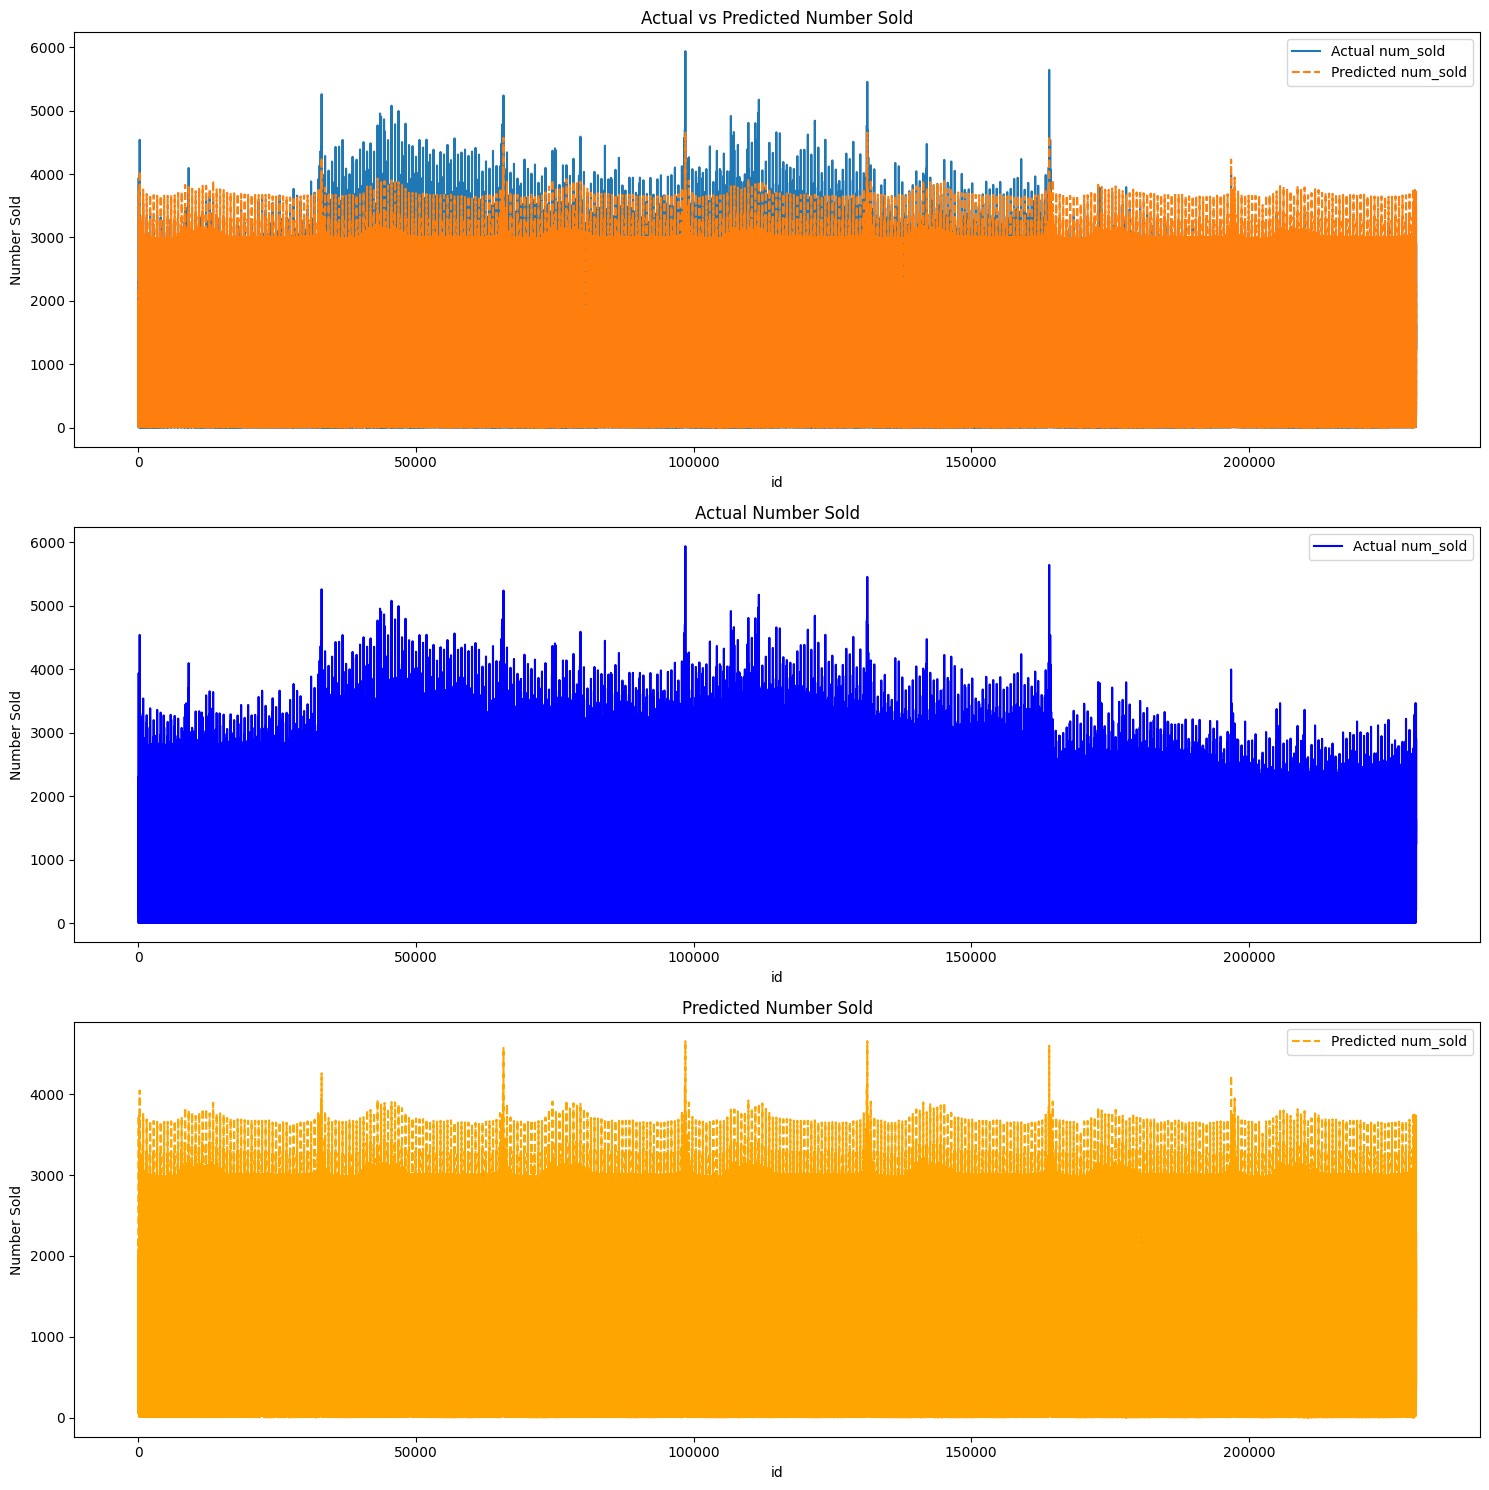

In [59]:
train_and_predict(train, 'cat',test)

[I 2025-01-14 10:39:11,542] A new study created in memory with name: no-name-9066f6de-6e96-4f7d-a5ad-c442074c4dfd


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 27
[LightGBM] [Info] Start training from score 751.724474


[I 2025-01-14 10:39:14,011] Trial 0 finished with value: 7.095450484604044 and parameters: {'n_estimators': 387, 'max_depth': 17, 'learning_rate': 0.0006385364753546588}. Best is trial 0 with value: 7.095450484604044.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 27
[LightGBM] [Info] Start training from score 751.724474


[I 2025-01-14 10:39:16,437] Trial 1 finished with value: 0.17119906833392623 and parameters: {'n_estimators': 657, 'max_depth': 25, 'learning_rate': 0.05677879436944652}. Best is trial 1 with value: 0.17119906833392623.


Best hyperparameters: {'n_estimators': 657, 'max_depth': 25, 'learning_rate': 0.05677879436944652}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 221259, number of used features: 27
[LightGBM] [Info] Start training from score 752.527382
There was a decimal number in the predictions.
Sum of all fractional parts: 106950.99968534854
Mean Absolute Percentage Error: 0.16437651694452435


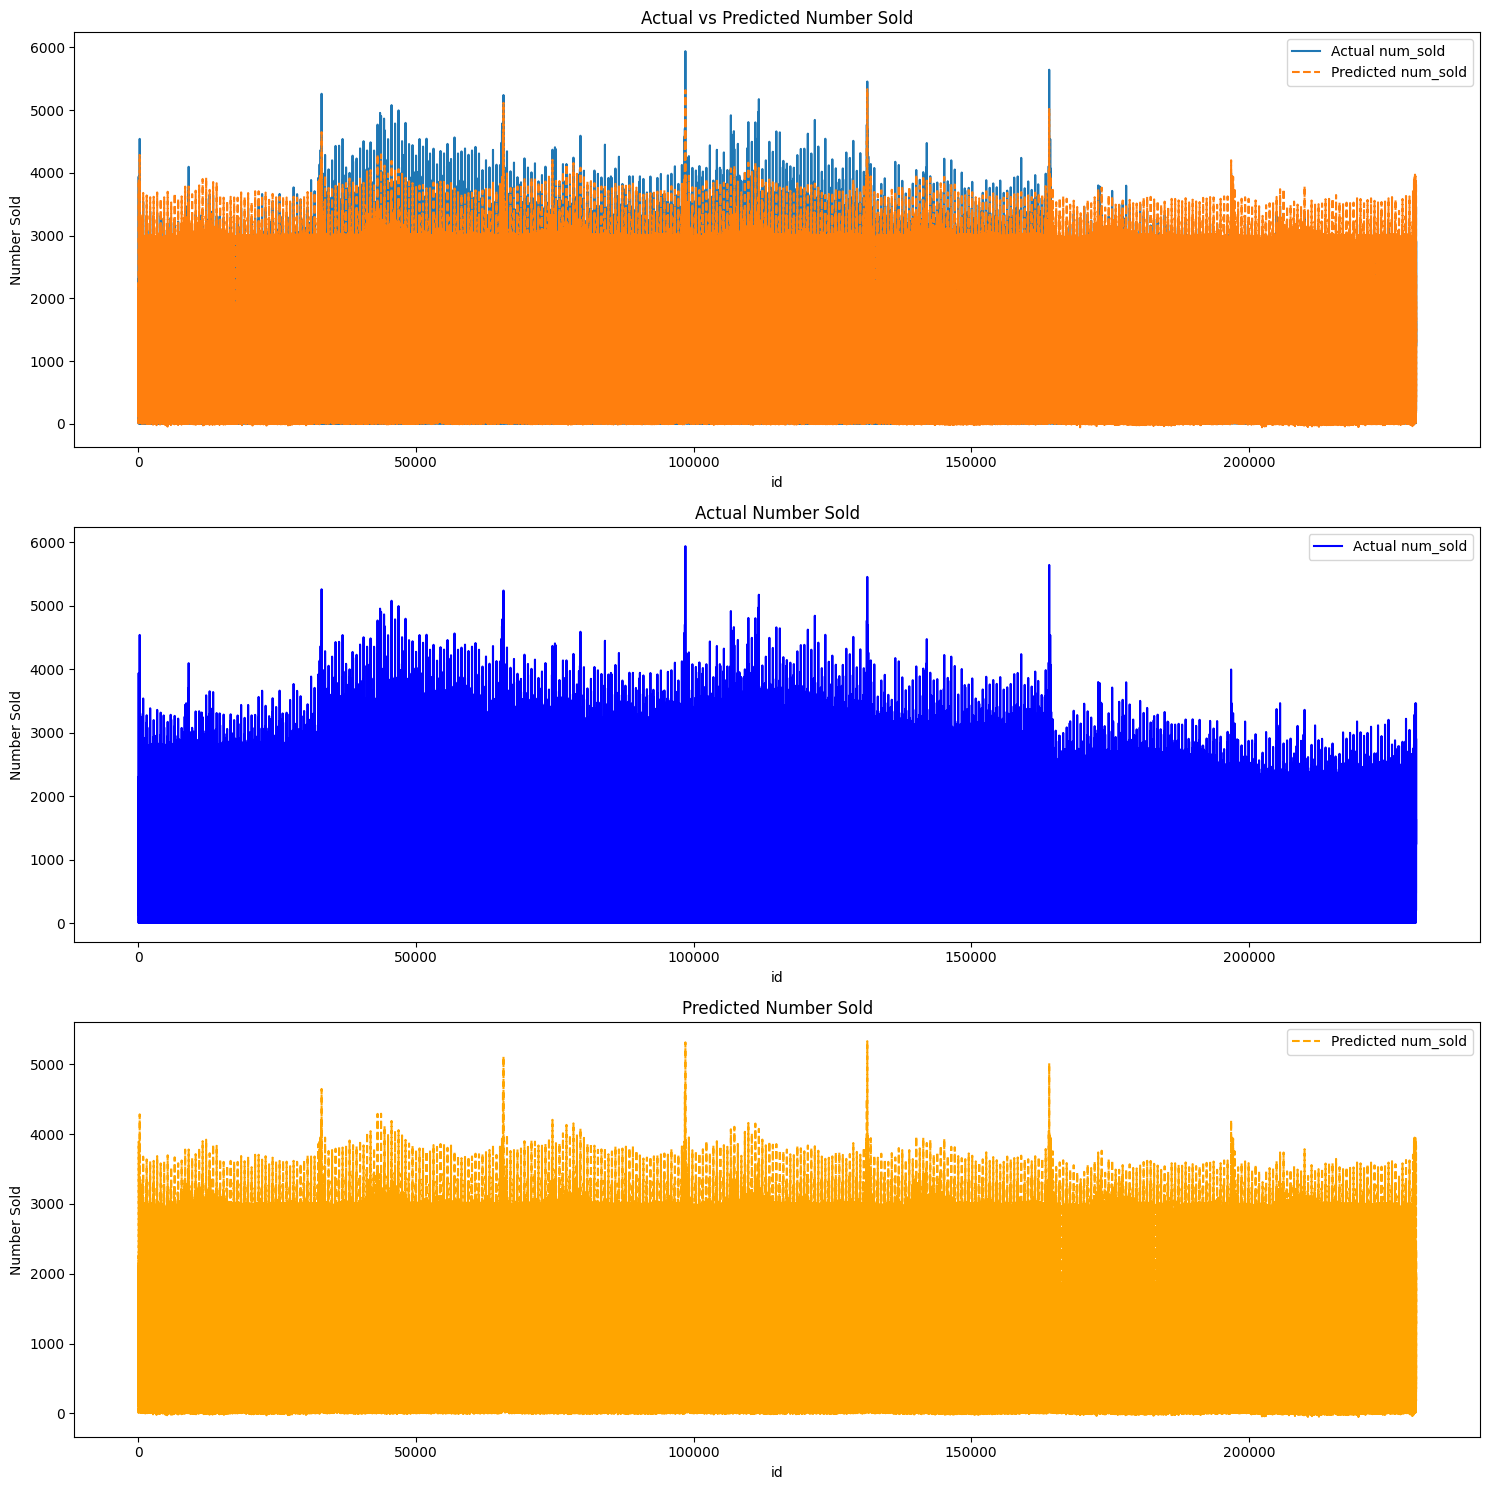

In [60]:
train_and_predict(train, 'lgbm',test)
